In [ ]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt

# Read the main csv
comb_df = pd.read_csv("Final_Dataset/combined/combined_data.csv")
comb_df.head()

,_id,dataset_material,vacancy_sites,substitution_sites,defect_sites,Formation_Energy,band_gap_value,strata
0,BN_B62C2N63_816498e1-eef8-400f-93d4-17a0a435389a,high_BN,1.0,2.0,3.0,20.845103,0.47870,0
1,BN_B62C1N63_631c0dc0-4762-4e3c-93ba-d4876a1b7997,high_BN,2.0,1.0,3.0,44.184872,0.59710,0
2,BN_B63C2N62_5ea09385-eb62-43dc-9334-9142794a8de0,high_BN,1.0,2.0,3.0,24.337552,0.84450,0
3,BN_B63C1N62_e4656f55-37a8-4fcf-bec1-fd7cc833f86b,high_BN,2.0,1.0,3.0,46.783747,0.87055,0
4,BN_B62C2N63_91fe1ce6-6a19-4a26-8caa-82caf4ca6ac2,high_BN,1.0,2.0,3.0,22.421006,1.84640,0


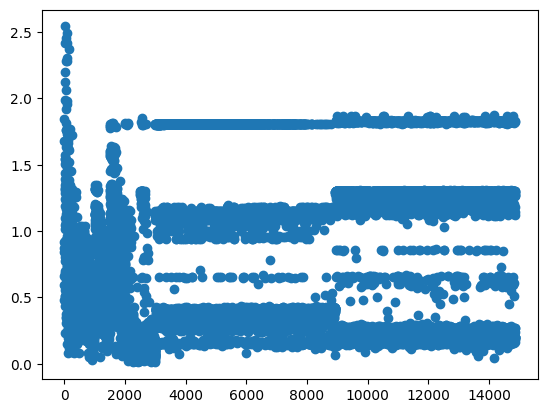

In [3]:
# Analyze the target

plt.scatter(np.linspace(1,len(comb_df), len(comb_df)), comb_df["band_gap_value"])
plt.show()

# What is causing the clustering of the band gap values?

## Maybe it is the material

/tmp/ipykernel_2933009/2623785457.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[i].legend()


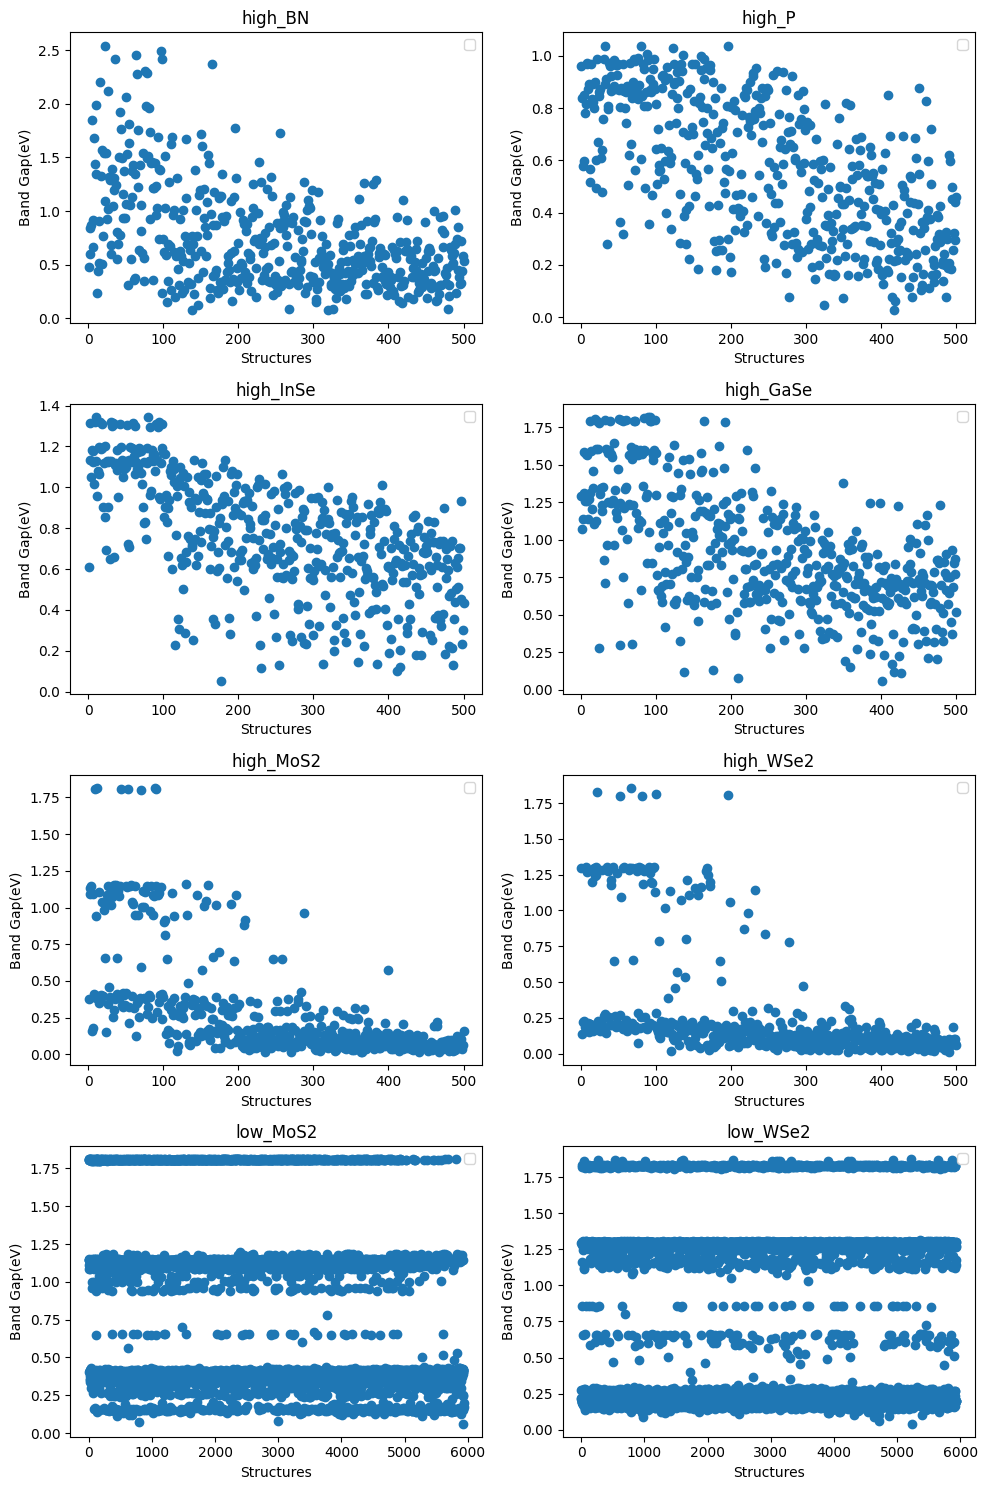

In [5]:
# Plot bgv values for the different material datasets
mat_datasets = comb_df["dataset_material"].unique()

# Plot the band gap for every material
fig, axs = plt.subplots(4, 2, figsize=(10, 15))
axs = axs.flatten()

for i, mat in enumerate(mat_datasets):
    mat_df = comb_df[comb_df["dataset_material"] == mat]
    len_mat = len(mat_df)

    axs[i].scatter(np.linspace(1,len_mat, len_mat), mat_df["band_gap_value"])
    axs[i].set_xlabel('Structures')
    axs[i].set_ylabel('Band Gap(eV)')
    axs[i].set_title(mat)
    axs[i].legend()

plt.tight_layout()
plt.show()

It seems like the structures with a low concentration of defects is causing this. 

Could it be because the less the number of defects, the less the change in the band gap of the pristine material?

In [ ]:
from sklearn.model_selection import train_test_split
import graphy_gnn
import torch

comb_df = pd.read_csv("Final_Dataset/combined/combined_data.csv")
sample_df = comb_df[comb_df["dataset_material"].isin(["high_BN", "high_InSe", "high_GaSe", "high_P"])]

train_set, test_set = train_test_split(sample_df, test_size=0.25, stratify=sample_df['strata'], random_state=42)
test_set, val_set = train_test_split(test_set, test_size=0.5, random_state=42, stratify=test_set["strata"])

well_distributed_train_graphs = graphy_gnn.fast_grapy(train_set)
well_distributed_val_graphs = graphy_gnn.fast_grapy(val_set)
well_distributed_test_graphs = graphy_gnn.fast_grapy(test_set)

well_distributed_train_graphs = graphy_gnn.get_ids_ratios(well_distributed_train_graphs)
well_distributed_val_graphs = graphy_gnn.get_ids_ratios(well_distributed_val_graphs)
well_distributed_test_graphs = graphy_gnn.get_ids_ratios(well_distributed_test_graphs)

# Save them 
torch.save(well_distributed_train_graphs, "Final_Dataset/gnn graphs/well_distributed_train_graphs.pt")
torch.save(well_distributed_val_graphs, "Final_Dataset/gnn graphs/well_distributed_val_graphs.pt")
torch.save(well_distributed_test_graphs, "Final_Dataset/gnn graphs/well_distributed_test_graphs.pt")


2000